In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv("C:\\Users\\cngan\\Downloads\\Mall_Customers (1).csv")

In [11]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
x=df[["Annual Income (k$)","Spending Score (1-100)"]]

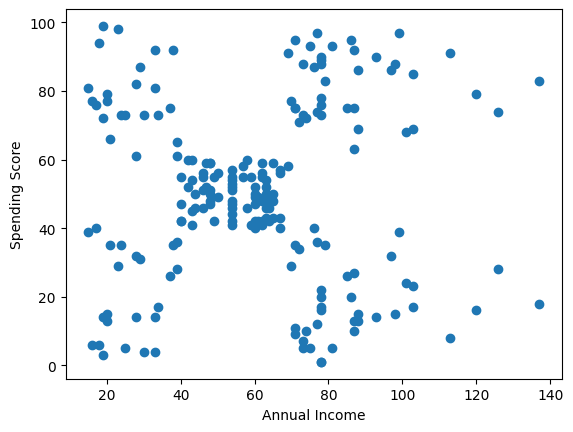

In [14]:
plt.scatter(x["Annual Income (k$)"],x["Spending Score (1-100)"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

Text(0, 0.5, 'WCSS scores')

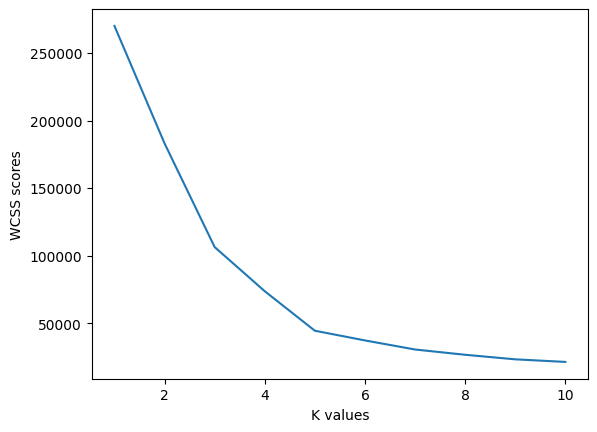

In [15]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.xlabel("K values")
plt.ylabel("WCSS scores")

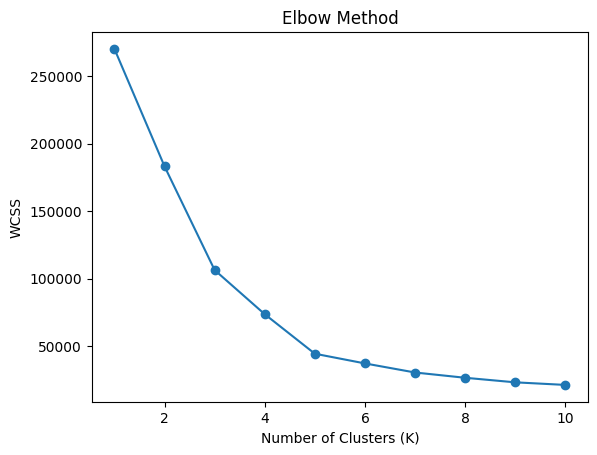

In [16]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
for k in range(2,11):

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)

    print("K =",k," Silhouette Score =",score)

K = 2  Silhouette Score = 0.39564531743995546
K = 3  Silhouette Score = 0.46761358158775435
K = 4  Silhouette Score = 0.4937945814354117
K = 5  Silhouette Score = 0.553931997444648
K = 6  Silhouette Score = 0.5128405328004378
K = 7  Silhouette Score = 0.5017174409749505
K = 8  Silhouette Score = 0.4962769338093321
K = 9  Silhouette Score = 0.45587414130065596
K = 10  Silhouette Score = 0.4426214845978157


In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(x)
centroids = kmeans.cluster_centers_

In [24]:
df['Cluster'] = labels

In [25]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
